In [ ]:
import sys, tensorflow as tf

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
details = tf.config.experimental.get_device_details(
    tf.config.list_physical_devices("GPU")[0]
)
print(details)


{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


In [ ]:
!pip -q install --upgrade --force-reinstall "numpy==2.1.3" "pandas==2.2.2"

In [ ]:
import numpy as np, pandas as pd, tensorflow as tf

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("tensorflow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


numpy: 2.1.3
pandas: 2.2.2
tensorflow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
import sklearn
import cv2
import matplotlib

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("Matplotlib:", matplotlib.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow: 2.19.0
NumPy: 2.1.3
Pandas: 2.2.2
scikit-learn: 1.8.0
OpenCV: 4.13.0
Matplotlib: 3.10.8
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT = "/content/drive/MyDrive/TB_Project"
folders = [
    PROJECT,
    f"{PROJECT}/data_raw",
    f"{PROJECT}/data_processed",
    f"{PROJECT}/models",
    f"{PROJECT}/results",
    f"{PROJECT}/figures",
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Created/checked folders:")
for f in folders:
    print(" -", f)


Created/checked folders:
 - /content/drive/MyDrive/TB_Project
 - /content/drive/MyDrive/TB_Project/data_raw
 - /content/drive/MyDrive/TB_Project/data_processed
 - /content/drive/MyDrive/TB_Project/models
 - /content/drive/MyDrive/TB_Project/results
 - /content/drive/MyDrive/TB_Project/figures


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yusufyagci","key":"a27f14f581e7b9f1984d308a248ae062"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets list | head

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saidaminsaidaxmadov/chocolate-sales                             Chocolate Sales                                         468320  2026-01-04 14:23:35.490000          12701        214  1.0              
nalisha/e-commerce-sales-and-profit-analysis-dataset            E-Commerce Sales & Profit Analysis Dataset               42383  2026-01-31 06:51:11.350000            711         26  1.0              
sonalshinde123/work-from-home-employee-burnout-dataset          Work From Home Employee Burnout Dataset                  27962  2026-01-31 03:28:22.227000            903         31  1.0              


In [ ]:
%cd /content/drive/MyDrive/TB_Project/data_raw

!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset


/content/drive/MyDrive/TB_Project/data_raw
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
 98% 647M/663M [00:03<00:00, 216MB/s]
100% 663M/663M [00:04<00:00, 171MB/s]


In [ ]:
!unzip -q tuberculosis-tb-chest-xray-dataset.zip

In [ ]:
import os
print(os.listdir("."))

['tuberculosis-tb-chest-xray-dataset.zip', 'TB_Chest_Radiography_Database']


In [ ]:
import os

base = "TB_Chest_Radiography_Database"
print(os.listdir(base))

['Normal.metadata.xlsx', 'Normal', 'README.md.txt', 'Tuberculosis.metadata.xlsx', 'Tuberculosis']


In [ ]:
DATA_ROOT = "/content/drive/MyDrive/TB_Project/data_raw/TB_Chest_Radiography_Database"

NORMAL_DIR = f"{DATA_ROOT}/Normal"
TB_DIR = f"{DATA_ROOT}/Tuberculosis"

import os
print("Normal images:", len(os.listdir(NORMAL_DIR)))
print("TB images:", len(os.listdir(TB_DIR)))


Normal images: 3500
TB images: 700


Normal shape: (512, 512, 3)
TB shape: (512, 512, 3)


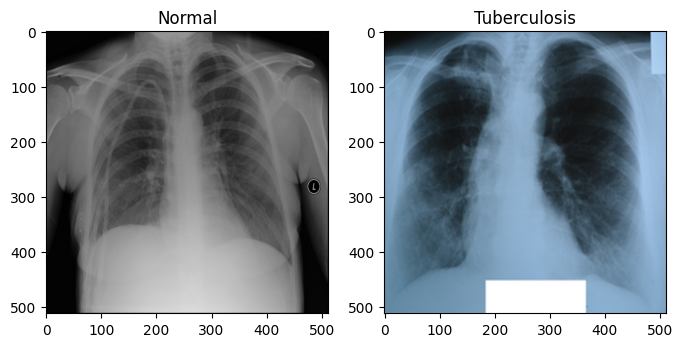

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

sample_normal = os.path.join(NORMAL_DIR, os.listdir(NORMAL_DIR)[0])
sample_tb = os.path.join(TB_DIR, os.listdir(TB_DIR)[0])

img_normal = cv2.imread(sample_normal)
img_tb = cv2.imread(sample_tb)

print("Normal shape:", img_normal.shape)
print("TB shape:", img_tb.shape)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_normal, cv2.COLOR_BGR2RGB))
plt.title("Normal")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img_tb, cv2.COLOR_BGR2RGB))
plt.title("Tuberculosis")

plt.show()


In [ ]:
import os, glob
import pandas as pd

DATA_ROOT = "/content/drive/MyDrive/TB_Project/data_raw/TB_Chest_Radiography_Database"
NORMAL_DIR = f"{DATA_ROOT}/Normal"
TB_DIR = f"{DATA_ROOT}/Tuberculosis"

def list_images(folder):
    exts = ("*.png", "*.jpg", "*.jpeg", "*.bmp")
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    return sorted(files)

normal_files = list_images(NORMAL_DIR)
tb_files = list_images(TB_DIR)

df = pd.DataFrame({
    "filepath": normal_files + tb_files,
    "label":   [0]*len(normal_files) + [1]*len(tb_files),  # 0=Normal, 1=TB
})

print("Total rows:", len(df))
print("Class counts:\n", df["label"].value_counts())
print("Example rows:\n", df.head(3))


Total rows: 4200
Class counts:
 label
0    3500
1     700
Name: count, dtype: int64
Example rows:
                                             filepath  label
0  /content/drive/MyDrive/TB_Project/data_raw/TB_...      0
1  /content/drive/MyDrive/TB_Project/data_raw/TB_...      0
2  /content/drive/MyDrive/TB_Project/data_raw/TB_...      0


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,           # 30% held out
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,           # split 30% into 15% / 15%
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain label counts:\n", train_df["label"].value_counts())
print("\nVal label counts:\n", val_df["label"].value_counts())
print("\nTest label counts:\n", test_df["label"].value_counts())


Train size: 2940
Val size: 630
Test size: 630

Train label counts:
 label
0    2450
1     490
Name: count, dtype: int64

Val label counts:
 label
0    525
1    105
Name: count, dtype: int64

Test label counts:
 label
0    525
1    105
Name: count, dtype: int64


In [ ]:
import os

SPLITS_DIR = "/content/drive/MyDrive/TB_Project/data_processed/splits"
os.makedirs(SPLITS_DIR, exist_ok=True)

train_path = os.path.join(SPLITS_DIR, "train_split.csv")
val_path   = os.path.join(SPLITS_DIR, "val_split.csv")
test_path  = os.path.join(SPLITS_DIR, "test_split.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("Saved:")
print(" -", train_path)
print(" -", val_path)
print(" -", test_path)


Saved:
 - /content/drive/MyDrive/TB_Project/data_processed/splits/train_split.csv
 - /content/drive/MyDrive/TB_Project/data_processed/splits/val_split.csv
 - /content/drive/MyDrive/TB_Project/data_processed/splits/test_split.csv


In [ ]:
import numpy as np

counts = train_df["label"].value_counts().sort_index()
n0, n1 = counts[0], counts[1]
total = n0 + n1

class_weight = {
    0: total / (2 * n0),
    1: total / (2 * n1)
}

print("Train counts:", dict(counts))
print("Class weights:", class_weight)
print("Weight ratio (TB/Normal):", class_weight[1] / class_weight[0])


Train counts: {0: np.int64(2450), 1: np.int64(490)}
Class weights: {0: np.float64(0.6), 1: np.float64(3.0)}
Weight ratio (TB/Normal): 5.0


In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)   # MobileNetV3 standard input
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df, shuffle=False):
    paths = df["filepath"].values
    labels = df["label"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)

print("Datasets created.") # Print to make sure the datasets are ready


Datasets created.


In [ ]:
for images, labels in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Min/Max pixel:", tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())


Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
Min/Max pixel: 0.0 1.0
